In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes as ax
import numpy as np
import csv
import tkinter as tk
from tkinter import filedialog

#for the dialogue window when choosing the file
root = tk.Tk()
root.withdraw

<bound method Wm.wm_withdraw of <tkinter.Tk object .>>

This code snippet is meant to take files issued from the Carry 50 in the (lab number) lab at the COPL and transform the CSV output files into graphs for visualization and potentially presentation in papers or presentations. We currently have problems with the array slicing (the slicing indices need to be figured out and input manually, a data type check upon encoding could work but doesn't seem worth it at the moment)

In [16]:
def csv_2_data(path, stop):
    with open(path) as file:
        content = csv.reader(file)
        raw_data = []
        for i in content:
            raw_data += [i[:-1]]
    return np.array(raw_data[2:stop]).astype(float)


This cell asks for the file to be opened and extracts data from it.

In [17]:
file = filedialog.askopenfilename()
print(f"file opened:{file}")
root.withdraw()

#stop is 403 for the dot samples and 353 for the fluo samples
spectrum = csv_2_data(file, 353)
wavelengths = spectrum[:,-2]
raw_abs = spectrum[:,-1]

file opened:C:/DATA/Université/Maitrise/PN2026/XM260422-7.csv


This cell simply plots the data onto a graph for visualization.

<function matplotlib.pyplot.show(close=None, block=None)>

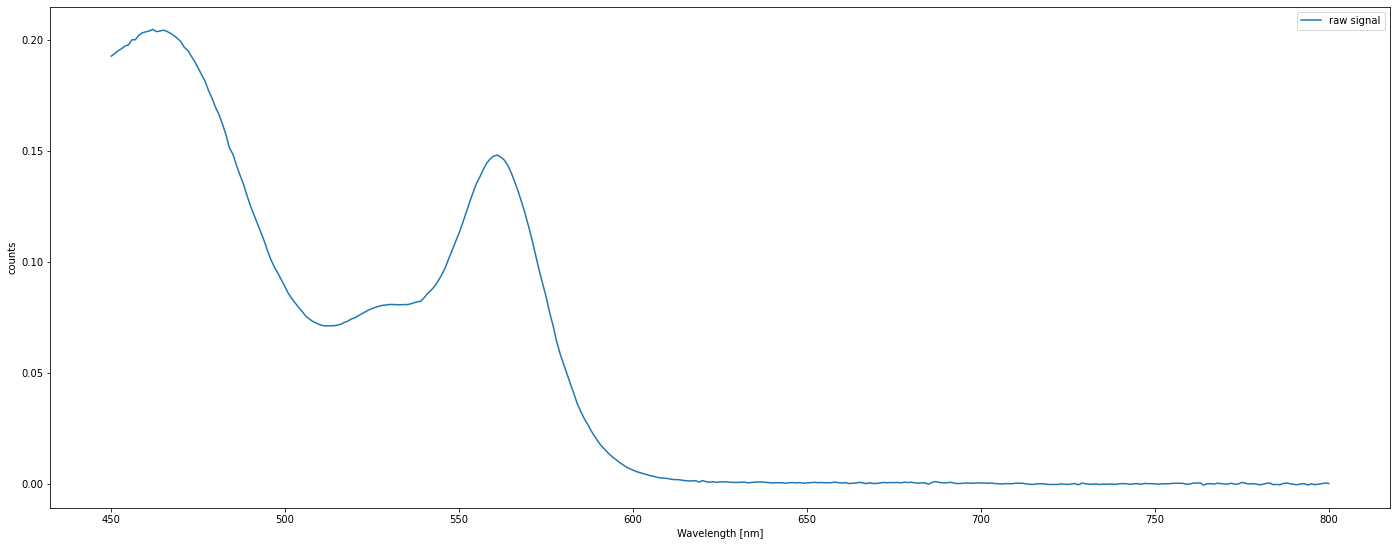

In [18]:
fig, ax = plt.subplots(figsize=(24, 12))
fig.subplots_adjust(bottom=0.3)

plt.plot(wavelengths, raw_abs, label = "raw signal")

#ax.tick_params("both", direction = "inout", top = True, right = True)
plt.xlabel("Wavelength [nm]")
plt.ylabel("counts")
#plt.xlim(350, 800)
plt.legend()
plt.show

Locating an absoption value:

In [19]:
def Abs_finder(spectrum, wavelength):
    ind = np.where(abs(spectrum[:, -2] - wavelength) <= 0.5)
    return float(spectrum[ind,-1])

print(Abs_finder(spectrum, 568.99))

0.1220756471
